<a href="https://colab.research.google.com/github/K1ng-cop/-Linear-Regression-Model-/blob/main/Linear_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
import pandas as pd
import numpy as np

In [4]:
import io
uploaded = files.upload()

Saving students_ai_usage.csv to students_ai_usage.csv


In [5]:
data = pd.read_csv('students_ai_usage.csv')

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X = data.drop(
    [
        'grades_after_ai',
        "purpose_of_ai",
        "ai_tools_used",
        "education_level"
    ],
    axis=1
)
y = data['grades_after_ai']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train["uses_ai"] = X_train["uses_ai"].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})
X_test["uses_ai"] = X_test["uses_ai"].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})

In [9]:
train_data = X_train.join(y_train)

In [10]:
train_data.corr()

,age,study_hours_per_day,uses_ai,grades_before_ai,daily_screen_time_hours,grades_after_ai
age,1.000000,-0.040362,0.065899,-0.039002,0.312434,0.037714
study_hours_per_day,-0.040362,1.000000,-0.122672,0.176615,-0.091839,0.059870
uses_ai,0.065899,-0.122672,1.000000,0.074219,0.052516,0.651856
grades_before_ai,-0.039002,0.176615,0.074219,1.000000,-0.002584,0.751215
daily_screen_time_hours,0.312434,-0.091839,0.052516,-0.002584,1.000000,0.046295
grades_after_ai,0.037714,0.059870,0.651856,0.751215,0.046295,1.000000


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'study_hours_per_day'}>],
       [<Axes: title={'center': 'uses_ai'}>,
        <Axes: title={'center': 'grades_before_ai'}>],
       [<Axes: title={'center': 'daily_screen_time_hours'}>,
        <Axes: title={'center': 'grades_after_ai'}>]], dtype=object)

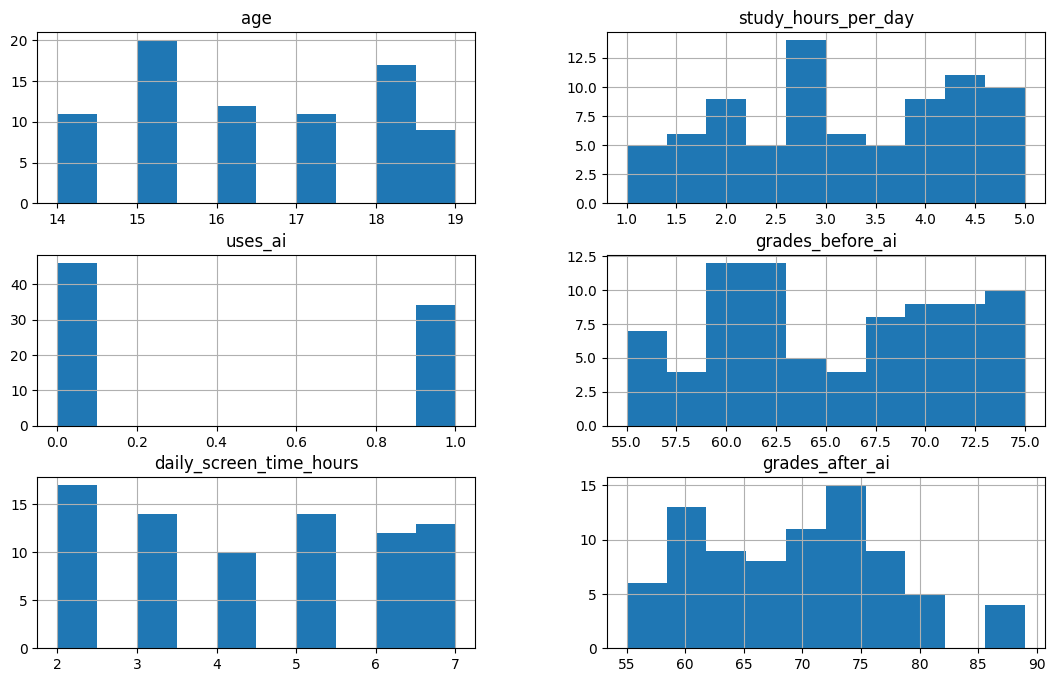

In [12]:
train_data.hist(figsize=(13,8))

<Axes: >

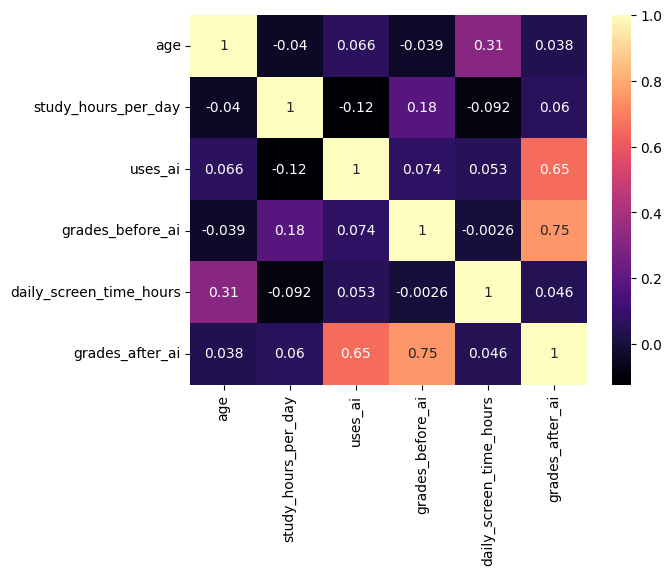

In [13]:
sns.heatmap(train_data.corr(), annot=True, cmap='magma')

In [14]:
from sklearn.linear_model import LinearRegression

X = data.drop(
    [
        'grades_after_ai',
        "purpose_of_ai",
        "ai_tools_used",
        "education_level"
    ],
    axis=1
)
y = data['grades_after_ai']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train["uses_ai"] = X_train["uses_ai"].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})

reg = LinearRegression()

reg.fit(X_train, y_train)

LinearRegression()

In [15]:
test_data = X_test.join(y_test)

X_test["uses_ai"] = X_test["uses_ai"].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})


In [16]:
reg.score(X_test, y_test)

0.9450127223461721

In [17]:
print(reg.coef_)

[0.11400723 0.07449818 9.81524525 0.96220296 0.04799434]


In [18]:
print(reg.intercept_)

0.14114722110666378


In [19]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': reg.coef_
})
display(coefficients)

,Feature,Coefficient
0,age,0.114007
1,study_hours_per_day,0.074498
2,uses_ai,9.815245
3,grades_before_ai,0.962203
4,daily_screen_time_hours,0.047994


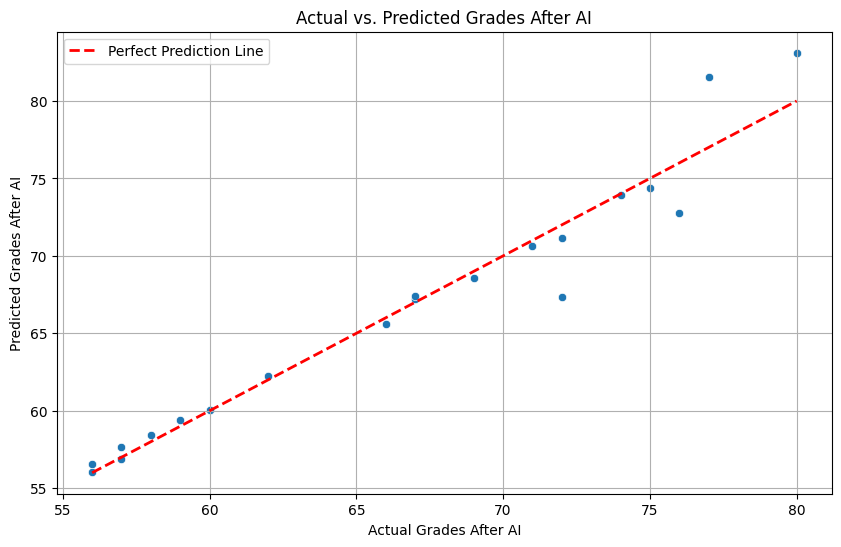

In [20]:
y_pred = reg.predict(X_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Grades After AI')
plt.ylabel('Predicted Grades After AI')
plt.title('Actual vs. Predicted Grades After AI')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.legend()
plt.grid(True)
plt.show()